In [1]:
import os
import farsight as fs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import synth_reader as sr
from astropy.io import fits
from astropy.table import Table
from joblib import Parallel, delayed

In [2]:
DF_original = pd.read_csv('~/HIIGalaxies/Spectral_synthesis/HIIGsample_stats.csv')


new_cols = ['STARLIGHT','FADO','LAMBDA_N','CHI2','ADEV','A_V','A_NEB','V_STAR','S_STAR',
            'MEAN_LGTL','MEAN_LGTM','MEAN_ZL','MEAN_ZM','MIT','MCT','LG_MIT','LG_MCT','SFR',
            'SSFR','RED_LAW','BASE_SRC','N_BASE']

# 3. Creamos las nuevas columnas vacías con MultiIndex
# Usamos un diccionario de tuplas para que Pandas entienda la jerarquía
for main in new_cols:
    DF_original[main] = None

#DF.loc[0, "sSFR"] = 3



In [3]:
class Results_reader:
    def __init__(self,home,data_frame,software,law_key): # Input file name & file directory and distance in Mpc o z
        self.home = home
        self.data_frame = data_frame
        self.software = software
        self.law_key = law_key

    def get_individual_data(self,idx = '', dist = None):
        if self.software == 'FADO':
            spec = fs.Fado(home = self.home,
                        file = idx,
                        distance = dist)
        if self.software == 'STARLIGHT':
            spec = fs.Starlight(home = self.home,
                        file = idx,
                        distance = dist)
        
        data = {'CHI2':      [  spec.metadata['chi2']                , r'$\mathbfit{\chi^2 / \nu}$'               ], 
                'ADEV':      [  spec.metadata['adev']                , r'$\mathbfit{Adev}$'                       ],
                'A_V':       [  spec.metadata['A_V']                 , r'$\mathbfit{A_{V\star}}$'                 ],
                'A_NEB':     [  spec.metadata['A_Neb']               , r'$\mathbfit{A_{V Neb}}$'                  ],
                'V_STAR':    [  spec.metadata['v_star']              , r'$\mathbfit{v {\star}}$'                  ],
                'S_STAR':    [  spec.metadata['s_star']              , r'$\mathbfit{\sigma {\star}}$'             ],
                'MEAN_LGTL': [  spec.metadata['mean_logt_L']         , r'$\mathbfit{\langle log\,t \rangle_L}$'   ],
                'MEAN_LGTM': [  spec.metadata['mean_logt_M']         , r'$\mathbfit{\langle log\,t \rangle_M}$'   ],
                'MEAN_ZL':   [  spec.metadata['mean_Z_L']            , r'$\mathbfit{\langle Z \rangle_L}$'        ], 
                'MEAN_ZM':   [  spec.metadata['mean_Z_M']            , r'$\mathbfit{\langle Z \rangle_M}$'        ],
                'MIT':       [  spec.metadata['minitot']             , r'$\mathbfit{MassINItotal}$'               ],
                'MCT':       [  spec.metadata['mcortot']             , r'$\mathbfit{MassCORtotal}$'               ],
                'LG_MIT':    [  spec.distance_derived['log_mitot']   , r'$\mathbfit{lgMassINItotal}$'             ],  
                'LG_MCT':    [  spec.distance_derived['log_mctot']   , r'$\mathbfit{lgMassCORtotal}$'             ],
                'SFR':       [  spec.distance_derived['sfr_0']       , r'$\mathbfit{SFR}$'                        ],
                'SSFR':      [  spec.distance_derived['ssfr_0']      , r'$\mathbfit{sSFR}$'                       ],
                'RED_LAW':   [  spec.metadata['red_law']             , r'$\mathbfit{Reddening \, law}$'           ],
                'BASE_SRC':  [  spec.metadata['base_src']            , r'$\mathbfit{Base \, source}$'             ],
                'N_BASE':    [  spec.metadata['n_base']              , r'$\mathbfit{N \, base}$'                  ],
                'LAMBDA_N':  [  spec.metadata['lambda_norm']         , r'$\mathbfit{\lambda (\AA)}$'              ]
                }
        
        return data


        

    def get_bulk_data(self):
        _cols = ['LAMBDA_N','CHI2','ADEV','A_V','A_NEB','V_STAR','S_STAR',
                 'MEAN_LGTL','MEAN_LGTM','MEAN_ZL','MEAN_ZM','MIT','MCT','LG_MIT','LG_MCT','SFR',
                 'SSFR','RED_LAW','BASE_SRC','N_BASE']
        path = self.home
        if self.software == 'FADO':
            spec_list = [f for f in os.listdir(path) if f.endswith('_1D.fits')]
            spec_list.sort()
        if self.software == 'STARLIGHT':
            spec_list = [f for f in os.listdir(path) if f.endswith('.out')]
            spec_list.sort()
        spec_list = [item for item in spec_list if self.law_key in item]
        DF = self.data_frame.copy()
        for file_name in spec_list:
            idx_val = int(file_name[0:3])
            mask = DF['TAB5_INDEX'] == idx_val
            z = DF.loc[mask, 'Z'].iloc[0]
            results = self.get_individual_data(idx = file_name, dist = z)
            DF.loc[mask, "FADO"] = (self.software == 'FADO')
            DF.loc[mask, "STARLIGHT"] = (self.software == 'STARLIGHT')
            for lbl in _cols:
                DF.loc[mask, lbl] = results[lbl][0]
        return DF
                

In [4]:
FD_CAL_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4020/',DF_original,'FADO','CALR').get_bulk_data()
FD_GD1_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4020/',DF_original,'FADO','GOR1').get_bulk_data()
FD_GD2_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4020/',DF_original,'FADO','GOR2').get_bulk_data()
FD_GD3_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4020/',DF_original,'FADO','GOR3').get_bulk_data()
print('Done')

FD_CAL_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_5100/',DF_original,'FADO','CALR').get_bulk_data()
FD_GD1_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_5100/',DF_original,'FADO','GOR1').get_bulk_data()
FD_GD2_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_5100/',DF_original,'FADO','GOR2').get_bulk_data()
FD_GD3_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_5100/',DF_original,'FADO','GOR3').get_bulk_data()
print('Done')

FD_CAL_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4150/',DF_original,'FADO','CALR').get_bulk_data()
FD_GD1_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4150/',DF_original,'FADO','GOR1').get_bulk_data()
FD_GD2_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4150/',DF_original,'FADO','GOR2').get_bulk_data()
FD_GD3_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4150/',DF_original,'FADO','GOR3').get_bulk_data()
print('Done')

SL_CAL_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4020/',DF_original,'STARLIGHT','CAL').get_bulk_data()
SL_GD1_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4020/',DF_original,'STARLIGHT','GD1').get_bulk_data()
SL_GD2_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4020/',DF_original,'STARLIGHT','GD2').get_bulk_data()
SL_GD3_4020 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4020/',DF_original,'STARLIGHT','GD3').get_bulk_data()
print('Done')

SL_CAL_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_5100/',DF_original,'STARLIGHT','CAL').get_bulk_data()
SL_GD1_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_5100/',DF_original,'STARLIGHT','GD1').get_bulk_data()
SL_GD2_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_5100/',DF_original,'STARLIGHT','GD2').get_bulk_data()
SL_GD3_5100 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_5100/',DF_original,'STARLIGHT','GD3').get_bulk_data()
print('Done')

SL_CAL_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4150/',DF_original,'STARLIGHT','CAL').get_bulk_data()
SL_GD1_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4150/',DF_original,'STARLIGHT','GD1').get_bulk_data()
SL_GD2_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4150/',DF_original,'STARLIGHT','GD2').get_bulk_data()
SL_GD3_4150 = Results_reader(os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4150/',DF_original,'STARLIGHT','GD3').get_bulk_data()
print('Done')

#s_srCAL_4020 = SL_CAL_4020[SL_CAL_4020['TAB5_INDEX']!=56]
#f_srCAL_4020 = FD_CAL_4020[FD_CAL_4020['TAB5_INDEX']!=56]
#s_srGD1_4020 = SL_GD1_4020[SL_GD1_4020['TAB5_INDEX']!=56]
#f_srGD1_4020 = FD_GD1_4020[FD_GD1_4020['TAB5_INDEX']!=56]
#s_srGD2_4020 = SL_GD2_4020[SL_GD2_4020['TAB5_INDEX']!=56]
#f_srGD2_4020 = FD_GD2_4020[FD_GD2_4020['TAB5_INDEX']!=56]
#s_srGD3_4020 = SL_GD3_4020[SL_GD3_4020['TAB5_INDEX']!=56]
#f_srGD3_4020 = FD_GD3_4020[FD_GD3_4020['TAB5_INDEX']!=56]

Done
Done
Done
Done
Done
Done


In [5]:
SL_CAL_4020['RED_LAW'] = np.unique(FD_CAL_4020['RED_LAW'])[0]
SL_CAL_5100['RED_LAW'] = np.unique(FD_CAL_5100['RED_LAW'])[0]
SL_CAL_4150['RED_LAW'] = np.unique(FD_CAL_4150['RED_LAW'])[0]

SL_GD1_4020['RED_LAW'] = np.unique(FD_GD1_4020['RED_LAW'])[0]
SL_GD1_5100['RED_LAW'] = np.unique(FD_GD1_5100['RED_LAW'])[0]
SL_GD1_4150['RED_LAW'] = np.unique(FD_GD1_4150['RED_LAW'])[0]

SL_GD2_4020['RED_LAW'] = np.unique(FD_GD2_4020['RED_LAW'])[0]
SL_GD2_5100['RED_LAW'] = np.unique(FD_GD2_5100['RED_LAW'])[0]
SL_GD2_4150['RED_LAW'] = np.unique(FD_GD2_4150['RED_LAW'])[0]

SL_GD3_4020['RED_LAW'] = np.unique(FD_GD3_4020['RED_LAW'])[0]
SL_GD3_5100['RED_LAW'] = np.unique(FD_GD3_5100['RED_LAW'])[0]
SL_GD3_4150['RED_LAW'] = np.unique(FD_GD3_4150['RED_LAW'])[0]

In [6]:
DF_stacked = pd.concat([FD_CAL_4020, FD_CAL_5100,FD_CAL_4150, 
                        FD_GD1_4020, FD_GD1_5100,FD_GD1_4150,
                        FD_GD2_4020, FD_GD2_5100,FD_GD2_4150,
                        FD_GD3_4020, FD_GD3_5100,FD_GD3_4150,
                        SL_CAL_4020, SL_CAL_5100,SL_CAL_4150, 
                        SL_GD1_4020, SL_GD1_5100,SL_GD1_4150,
                        SL_GD2_4020, SL_GD2_5100,SL_GD2_4150,
                        SL_GD3_4020, SL_GD3_5100,SL_GD3_4150,
                        ], axis=0, ignore_index=True)

DF_stacked['A_NEB'] = pd.to_numeric(DF_stacked['A_NEB'], errors='coerce')
DF_stacked['MEAN_LGTL'] = DF_stacked['MEAN_LGTL'].astype('float64')
DF_stacked['MEAN_LGTM'] = DF_stacked['MEAN_LGTM'].astype('float64')
DF_stacked['MIT'] = DF_stacked['MIT'].astype('float64')
DF_stacked['MCT'] = DF_stacked['MCT'].astype('float64')

for col in DF_stacked.columns:
    if DF_stacked[col].dtype == 'object':
        try:
            temp_numeric = pd.to_numeric(DF_stacked[col], errors='raise')
            DF_stacked[col] = temp_numeric
        except (ValueError, TypeError):
            DF_stacked[col] = DF_stacked[col].astype(str)
            DF_stacked[col] = DF_stacked[col].replace(['None', 'nan', 'NaN'], '')

Final_table = Table.from_pandas(DF_stacked)

In [7]:
fits_name = 'Synthesis_runs.fits'
rands_x1hdu = np.random.random((1,1))
primary_hdu = fits.PrimaryHDU(data=rands_x1hdu)
HDU = fits.HDUList([primary_hdu])
lista_HDUs = [primary_hdu]
HDU_final = fits.HDUList(lista_HDUs)
HDU_final.writeto(fits_name, overwrite=True)
HDR = fits.Header()
HDR.insert(0,('TABLE', 'CONCATENATED', 'Concatenaded Table of Starlight and Fado Results'))
HDR.insert(1, ('COMMENT','121 spectra. 4 extintion laws and 3 lambda norm'))
hdu = fits.BinTableHDU(data = Final_table,header = HDR, name = 'Synthesis')
lista_HDUs.append(hdu)
HDU_final = fits.HDUList([primary_hdu,hdu])
HDU_final.writeto(fits_name, overwrite=True)

In [8]:

Final_table

SDSS_PMF,TAB5_INDEX,NED_NAME,PLATE,MJD,FIBERID,RA,DEC,Z,DESI_DR1,SDSS_SNR,STARLIGHT,FADO,LAMBDA_N,CHI2,ADEV,A_V,A_NEB,V_STAR,S_STAR,MEAN_LGTL,MEAN_LGTM,MEAN_ZL,MEAN_ZM,MIT,MCT,LG_MIT,LG_MCT,SFR,SSFR,RED_LAW,BASE_SRC,N_BASE
str25,int64,str25,int64,int64,int64,float64,float64,float64,bool,float64,bool,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str35,str16,int64
spSpec-51793-0388-457.fit,1,UM 199,388,51793,457,1.73758544441037,0.857230431344045,0.07368165,True,9.05,False,True,4020.0,0.7884,18.505679242943955,0.0003655,0.1857,68.13,116.6,6.687563896179199,6.809551239013672,0.5834249628071225,0.641039481080674,708.671875,646.7295532226562,7.389882785355698,7.350160295161924,6.329242202813491,2.5791044447033197e-07,Calzetti et al. (2000),Base_MILESM.Sbmm,150
spSpec-52138-0652-090.fit,2,SHOC 008,652,52138,90,4.19900692273353,-10.7950668290856,0.02324598,False,24.49,False,True,4020.0,0.7526,9.141213621768651,0.622,0.8279,-46.27,77.58,7.244472980499268,9.433920860290527,0.383443268158661,0.5899587501129299,128329.7265625,70691.0546875,8.614729228754392,8.35576642109837,701.392006485425,1.703066409952499e-06,Calzetti et al. (2000),Base_MILESM.Sbmm,150
spSpec-52145-0653-462.fit,3,SHOC 014,653,52145,462,5.91504256562465,-9.81353480088271,0.05303453,False,12.74,False,True,4020.0,0.7942,13.400350018448409,0.1705,0.6548,-25.63,58.21,6.8824663162231445,8.054852485656738,0.9499477946122418,0.5166085152181299,5391.15771484375,3823.0673828125,7.973100381854995,7.823830297504114,29.99448944442563,3.191104982633496e-07,Calzetti et al. (2000),Base_MILESM.Sbmm,150
spSpec-52233-0753-094.fit,4,2MASS J00242593+1404094,753,52233,94,6.10809542060741,14.0695495109622,0.01424038,False,28.36,False,True,4020.0,1.113,7.376785326679035,0.07538,-0.05,18.61,121.6,7.447125434875488,7.70114803314209,0.5962847750080875,0.5107249108505258,21516.45703125,16438.234375,7.4077346497081935,7.290819057438331,61.89253984496559,2.420492020237438e-06,Calzetti et al. (2000),Base_MILESM.Sbmm,150
spSpec-51817-0418-302.fit,5,SHOC 022,418,51817,302,8.07750453626596,15.0039393153258,0.01788816,False,25.88,False,True,4020.0,0.8578,8.506099544817353,0.3537,0.117,14.74,108.1,7.013338088989258,7.266829490661621,0.33956123710417613,0.33009126191376337,9527.8603515625,7967.4306640625,7.254400304632871,7.176723214250087,39.84699012530835,2.218171993172858e-06,Calzetti et al. (2000),Base_MILESM.Sbmm,150
spSpec-51913-0394-472.fit,6,UM 282,394,51913,472,12.9470306991655,0.161116101734004,0.03755626,True,20.37,False,True,4020.0,1.08,9.512561513913026,0.2801,0.004783,-69.72,63.02,6.959506034851074,7.2451348304748535,0.4931444772302588,0.6737325669461475,2110.245361328125,1765.80126953125,7.256439063052054,7.179047933482574,9.36126573016567,5.186752325182922e-07,Calzetti et al. (2000),Base_MILESM.Sbmm,150
spSpec-52146-0658-312.fit,7,SHOC 043,658,52146,312,14.0094359946736,-10.1693922667689,0.05817448,False,14.0,False,True,4020.0,0.8928,13.640327282131182,0.08121,0.5093,67.62,122.1,6.931064605712891,8.352598190307617,0.4981385464237469,2.1046578116515926,5265.92041015625,3553.34814453125,8.046366770897093,7.875530240280918,29.900876296196586,2.687306145809445e-07,Calzetti et al. (2000),Base_MILESM.Sbmm,150
spSpec-52147-0662-466.fit,8,SHOC 072,662,52147,466,23.2439274152965,-8.89383954755804,0.09524661,False,16.71,False,True,4020.0,0.8744,12.897112002068296,0.4709,0.03391,33.07,114.3,6.9777045249938965,7.115848541259766,0.3875951012818804,0.3036605752556353,3267.429931640625,2822.95849609375,8.28920176852667,8.22569997847455,192.88318343946312,9.910432244885851e-07,Calzetti et al. (2000),Base_MILESM.Sbmm,150
spSpec-51820-0400-441.fit,9,UM 336,400,51820,441,23.4359526850297,0.953121139115853,0.01924106,True,11.92,False,True,4020.0,0.8614,12.695600522444552,0.6779,0.07832,-70.59,107.9,6.856207847595215,7.033069610595703,0.37421701793811846,0.2916499186584619,1728.6776123046875,1507.8355712890625,6.577

In [148]:
s_4020_cut = Final_table[(Final_table['LAMBDA_N']== 4020)&(Final_table['TAB5_INDEX']!=56)&(Final_table['SDSS_SNR']>=10)&(Final_table['RED_LAW']=='Gordon et al. 2003 - SMC Bar')]

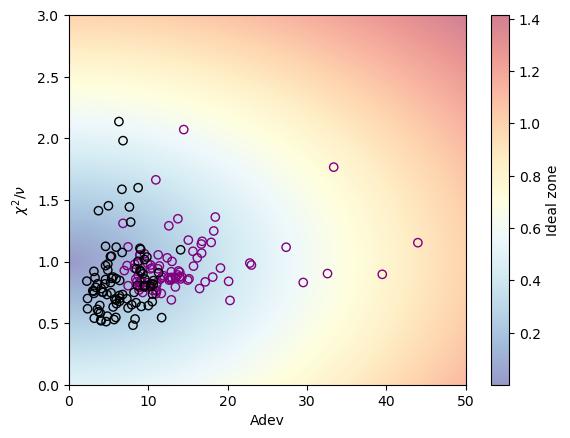

In [151]:
# 1. Crear la malla con tus rangos específicos
x = np.linspace(0, 50, 500)
y = np.linspace(0, 3, 500)
X, Y = np.meshgrid(x, y)

# 2. Normalizar las distancias para que X e Y pesen lo mismo
# Escalamos X (0 a 50) para que actúe como (0 a 1)
# Escalamos Y (0 a 3) para que actúe como (0 a 1)
x_norm = (X - 0) / 50
y_norm = (Y - 1) / 2  # Distancia relativa al punto 1 en un rango de 3

# 3. Calcular la distancia combinada usando los valores normalizados
Z = np.sqrt(x_norm**2 + y_norm**2)

# 4. Graficar
fig, ax = plt.subplots()
im = ax.imshow(Z, extent=[0, 50, 0, 3], origin='lower', cmap='RdYlBu_r', aspect='auto',alpha=0.5)

fd_g3 = s_4020_cut[(s_4020_cut['FADO']==True)  &  (s_4020_cut['RED_LAW']=='Gordon et al. 2003 - SMC Bar')]

sl_g3 = s_4020_cut[(s_4020_cut['STARLIGHT']==True)  &  (s_4020_cut['RED_LAW']=='Gordon et al. 2003 - SMC Bar')]




ax.scatter(fd_g3['ADEV'],
           fd_g3['CHI2'],
           marker = 'o',facecolors='none', edgecolors='purple')
ax.scatter(sl_g3['ADEV'],
           sl_g3['CHI2'],
           marker = 'o',facecolors='none', edgecolors='black')


# 5. Estética
#ax.set_title('Mapa de Calor Equilibrado (Objetivo X=0, Y=1)')
ax.set_xlabel(r'Adev')
ax.set_ylabel(r'$\chi^{2}/\nu$')
plt.colorbar(im, label='Ideal zone')

# Opcional: Dibujar un punto en el objetivo para verificar
#ax.plot(0, 1, 'ko', markersize=10, label='Objetivo (0,1)') 

plt.show()

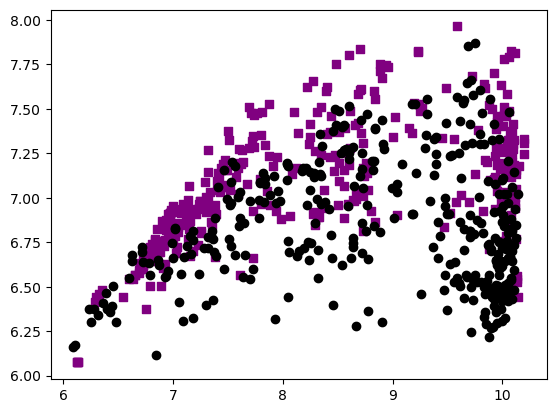

In [107]:
plt.scatter(s_4020_cut[s_4020_cut['FADO']==True]['MEAN_LGTM'],s_4020_cut[s_4020_cut['FADO']==True]['MEAN_LGTL'],marker = 's',facecolors='purple', edgecolors='purple')
plt.scatter(s_4020_cut[s_4020_cut['STARLIGHT']==True]['MEAN_LGTM'],s_4020_cut[s_4020_cut['STARLIGHT']==True]['MEAN_LGTL'],marker = 'o',facecolors='black', edgecolors='black')

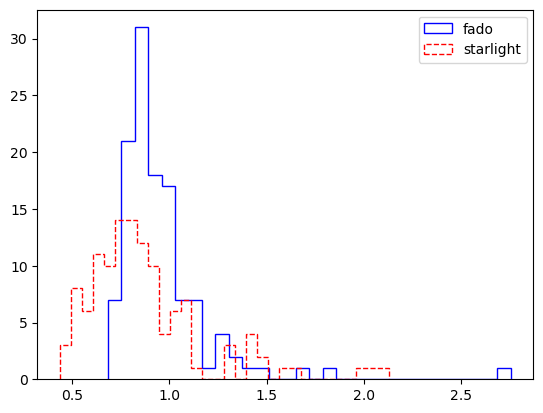

In [15]:
plt.hist(s_4020_CAL[s_4020_CAL['FADO']==True]['CHI2'], bins=30, alpha=1, color='blue', edgecolor='blue',histtype='step',label = 'fado',linestyle='-')
plt.hist(s_4020_CAL[s_4020_CAL['STARLIGHT']==True]['CHI2'], bins=30, alpha=1, color='blue', edgecolor='red',histtype='step',label = 'starlight',linestyle='--')
#plt.hist(f_srCAL['SFR'], bins=30, alpha=1, color='blue', edgecolor='red',histtype='step',label = 'fado',linestyle='--')

plt.legend()

In [114]:
np.unique(Final_table['LAMBDA_N'])

4020.0
4150.0
5100.0


In [141]:
icut = Final_table[(Final_table['TAB5_INDEX']!=56)&(Final_table['SDSS_SNR']>=10)&(Final_table['FADO']>=True)]

data = [icut[(icut['LAMBDA_N']==np.unique(Final_table['LAMBDA_N'])[0])&(icut['RED_LAW']==np.unique(Final_table['RED_LAW'])[0])]['CHI2'],
        icut[(icut['LAMBDA_N']==np.unique(Final_table['LAMBDA_N'])[0])&(icut['RED_LAW']==np.unique(Final_table['RED_LAW'])[1])]['CHI2'],
        icut[(icut['LAMBDA_N']==np.unique(Final_table['LAMBDA_N'])[0])&(icut['RED_LAW']==np.unique(Final_table['RED_LAW'])[2])]['CHI2'],
        icut[(icut['LAMBDA_N']==np.unique(Final_table['LAMBDA_N'])[0])&(icut['RED_LAW']==np.unique(Final_table['RED_LAW'])[3])]['CHI2'],
        icut[(icut['LAMBDA_N']==np.unique(Final_table['LAMBDA_N'])[1])&(icut['RED_LAW']==np.unique(Final_table['RED_LAW'])[0])]['CHI2'],
        icut[(icut['LAMBDA_N']==np.unique(Final_table['LAMBDA_N'])[1])&(icut['RED_LAW']==np.unique(Final_table['RED_LAW'])[1])]['CHI2'],
        icut[(icut['LAMBDA_N']==np.unique(Final_table['LAMBDA_N'])[1])&(icut['RED_LAW']==np.unique(Final_table['RED_LAW'])[2])]['CHI2'],
        icut[(icut['LAMBDA_N']==np.unique(Final_table['LAMBDA_N'])[1])&(icut['RED_LAW']==np.unique(Final_table['RED_LAW'])[3])]['CHI2'],
        icut[(icut['LAMBDA_N']==np.unique(Final_table['LAMBDA_N'])[2])&(icut['RED_LAW']==np.unique(Final_table['RED_LAW'])[0])]['CHI2'],
        icut[(icut['LAMBDA_N']==np.unique(Final_table['LAMBDA_N'])[2])&(icut['RED_LAW']==np.unique(Final_table['RED_LAW'])[1])]['CHI2'],
        icut[(icut['LAMBDA_N']==np.unique(Final_table['LAMBDA_N'])[2])&(icut['RED_LAW']==np.unique(Final_table['RED_LAW'])[2])]['CHI2'],
        icut[(icut['LAMBDA_N']==np.unique(Final_table['LAMBDA_N'])[2])&(icut['RED_LAW']==np.unique(Final_table['RED_LAW'])[3])]['CHI2']
        ]





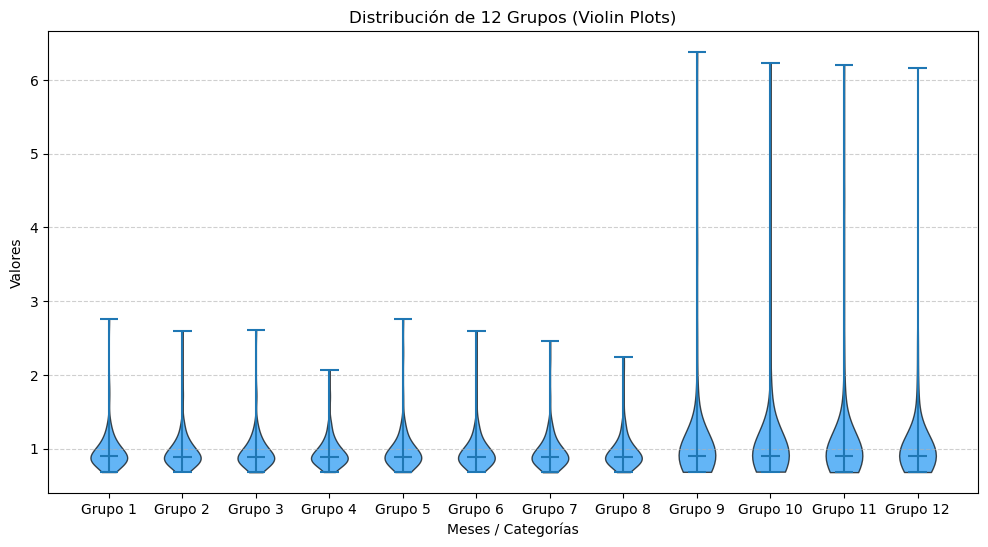

In [142]:
# 1. Crear 12 conjuntos de datos aleatorios
# Generamos una lista con 12 arrays, cada uno con 100 valores
#data = [np.random.normal(0, std, 100) for std in np.arange(1, 13, 1)]

fig, ax = plt.subplots(figsize=(12, 6))

# 2. Crear los violin plots
# showmeans muestra la media, showmedians la mediana

parts = ax.violinplot(data, showmeans=False, showmedians=True)

# 3. Personalizar colores (opcional)
for pc in parts['bodies']:
    pc.set_facecolor('#2196F3') # Un color azul vibrante
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

#bp = ax.boxplot(data, patch_artist=True, notch=False)#,showfliers=False)
#for box in bp['boxes']:
#    box.set(facecolor='#4CAF50', edgecolor='black')


# 4. Configurar el eje X para que muestre los 12 lugares
ax.set_xticks(range(1, 13))
ax.set_xticklabels([f'Grupo {i}' for i in range(1, 13)])

# 5. Etiquetas de apoyo
ax.set_title('Distribución de 12 Grupos (Violin Plots)')
ax.set_xlabel('Meses / Categorías')
ax.set_ylabel('Valores')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

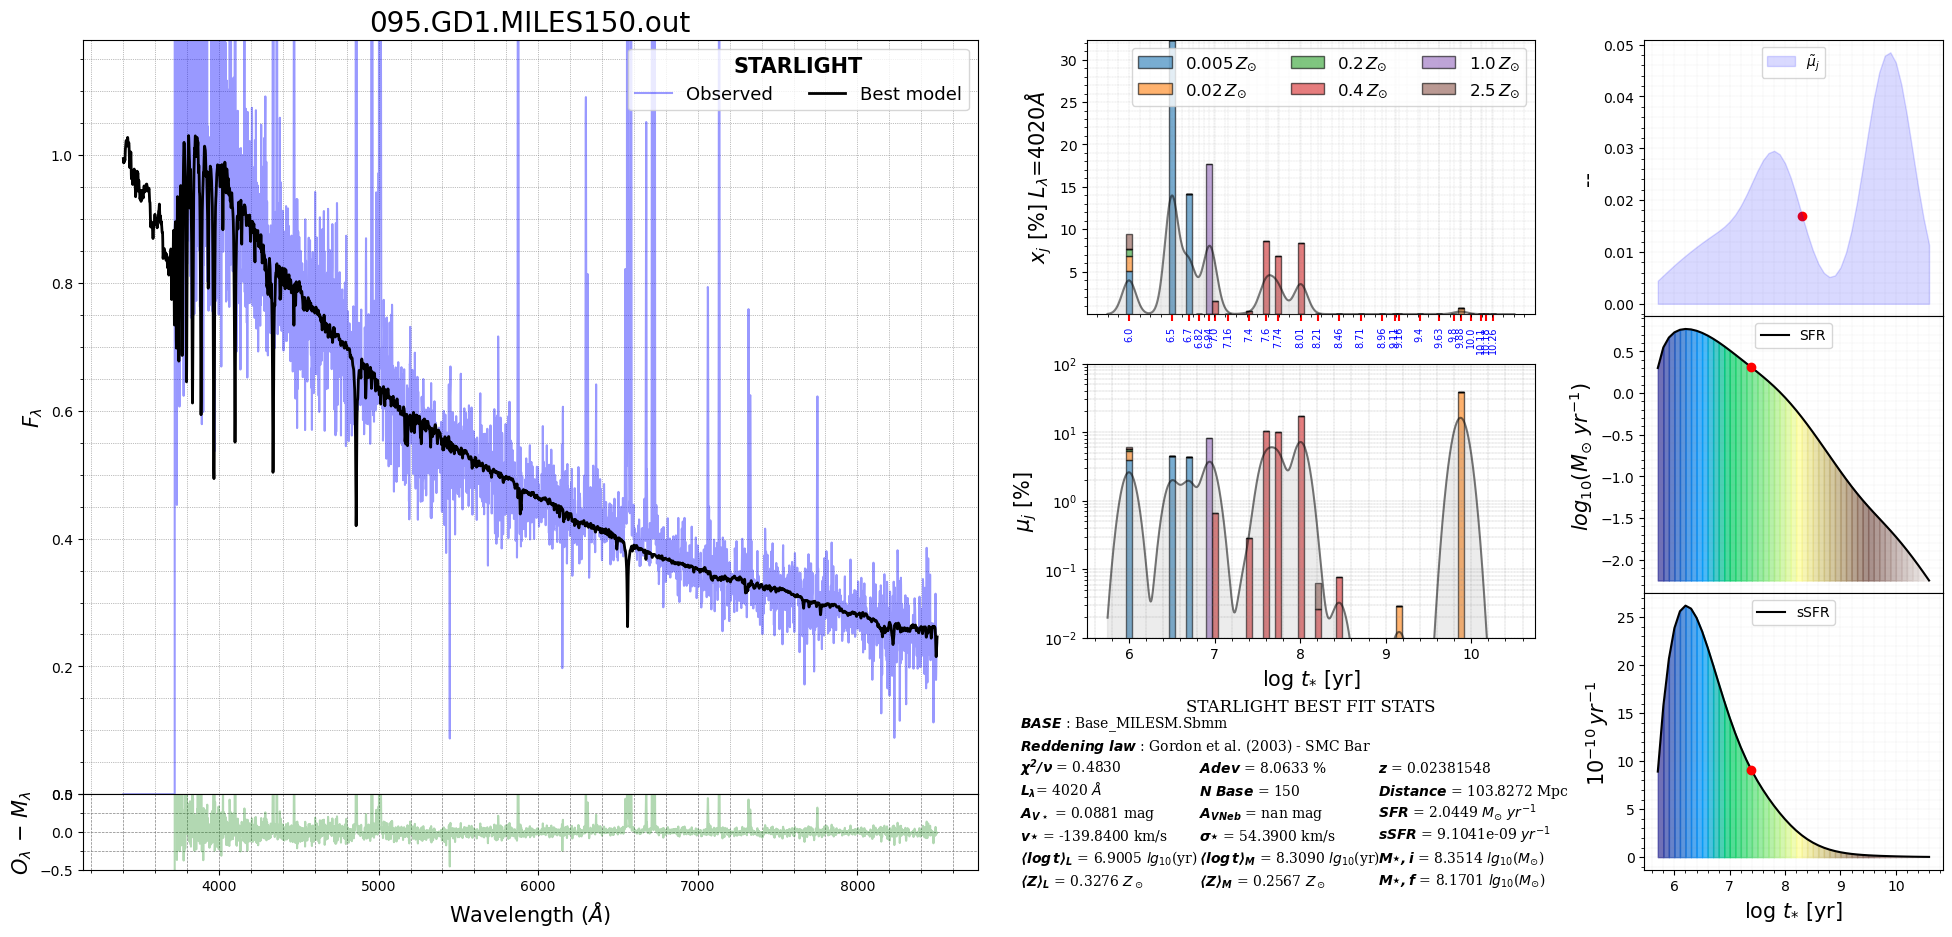

In [56]:
obj = '095'

spec = fs.Starlight(home = os.path.expanduser('~') +'/HIIGalaxies/STARLIGHT/output_4020/',
                    file = f'{obj}.GD1.MILES150.out', 
                    distance = DF_original[DF_original['TAB5_INDEX']>=int(obj)]['Z'].iloc[0])

spec.CompositePlot()


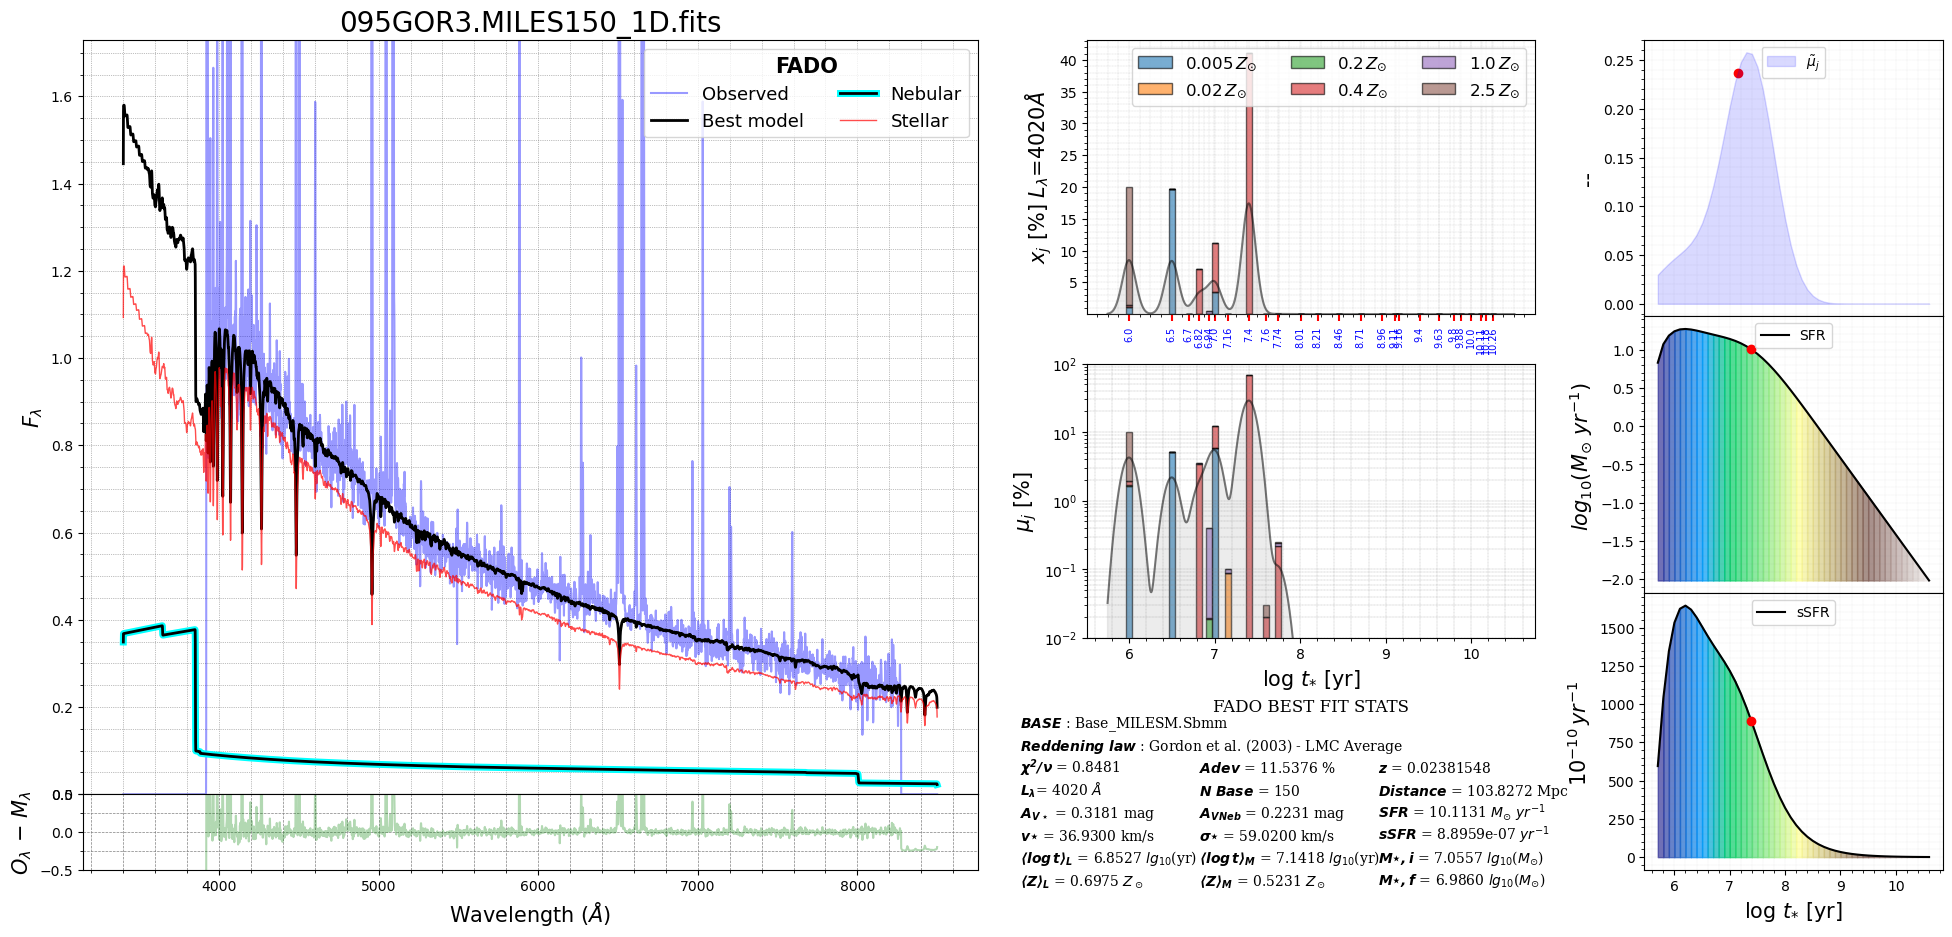

In [57]:
obj = '095'

spec = fs.Fado(home = os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4020/',
               file = f'{obj}GOR3.MILES150_1D.fits', 
               distance = DF_original[DF_original['TAB5_INDEX']>=int(obj)]['Z'].iloc[0])

spec.CompositePlot()


In [39]:
def merit_stats(path, title, snr_threshold, DF_path, 
                ext_laws=['Calzetti','Gordon1','Gordon2','Gordon3'], 
                attributes=[[r'$\chi^2$', 'Adev'], [0, 1]]):
    
    # 1. Filtro de SNR
    df_data = pd.read_csv(DF_path)
    valid_ids = df_data.loc[df_data['SDSS_SNR'] >= snr_threshold, 'TAB5_INDEX'].astype(str).tolist()
    
    # 2. Filtrar archivos (rellenamos con ceros si el ID en el nombre tiene formato 001)
    spec_list = [f for f in os.listdir(path) if f.endswith('_1D.fits')]
    chosen_spec = [f for f in spec_list if f[:3].lstrip('0') in [i.lstrip('0') for i in valid_ids]]
    chosen_spec.sort()

    # 3. Preparar estructura de resultados: una lista por cada celda del subplot
    # Si hay 2 atributos y 4 leyes, necesitamos 8 listas
    num_attrs = len(attributes[0])
    num_laws = len(ext_laws)
    results = [[] for _ in range(num_attrs * num_laws)]
    
    # Mapeo de keywords en el nombre de archivo a su índice de columna
    law_map = {'CALR': 0, 'GOR1': 1, 'GOR2': 2, 'GOR3': 3}

    # 4. Lectura de datos
    for filename in chosen_spec:
        # Identificar qué ley de extinción es
        law_idx = next((idx for key, idx in law_map.items() if key in filename), None)
        
        if law_idx is not None:
            # Leer el archivo una sola vez por eficiencia
            full_data = sr.FADO_results_reader(id=filename, home=path)
            
            for attr_row in range(num_attrs):
                # El índice final es: (fila_atributo * total_columnas) + columna_ley
                final_idx = (attr_row * num_laws) + law_idx
                val = full_data[attributes[1][attr_row]]
                results[final_idx].append(val)

    # 5. Graficar
    fig, axes = plt.subplots(nrows=num_attrs, ncols=num_laws, 
                             figsize=(16, 4 * num_attrs), sharey=False)
    fig.suptitle(title, fontsize=20, fontweight='bold')
    
    label_extlaws = ext_laws * num_attrs
    name_col = [label for label in attributes[0] for _ in range(num_laws)]

    for i, ax in enumerate(axes.flat):
        if not results[i]: continue # Evitar error si una lista quedó vacía
        
        ax.hist(results[i], bins=25, color='skyblue', edgecolor='black', alpha=0.7)
        
        stats = [np.mean(results[i]), np.median(results[i]), np.max(results[i]), np.min(results[i])]
        colors = ['r', 'g', 'b', 'c']
        labels = ['Mean', 'Median', 'Max', 'Min']
        
        for s, c, l in zip(stats, colors, labels):
            ax.axvline(s, color=c, linestyle='dashed', linewidth=2, label=f'{l}: {s:.2f}')
        
        ax.set_title(label_extlaws[i])
        ax.set_xlabel(name_col[i], fontsize=12, color='darkred')
        ax.legend(title=f'N = {len(results[i])}', fontsize='small')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

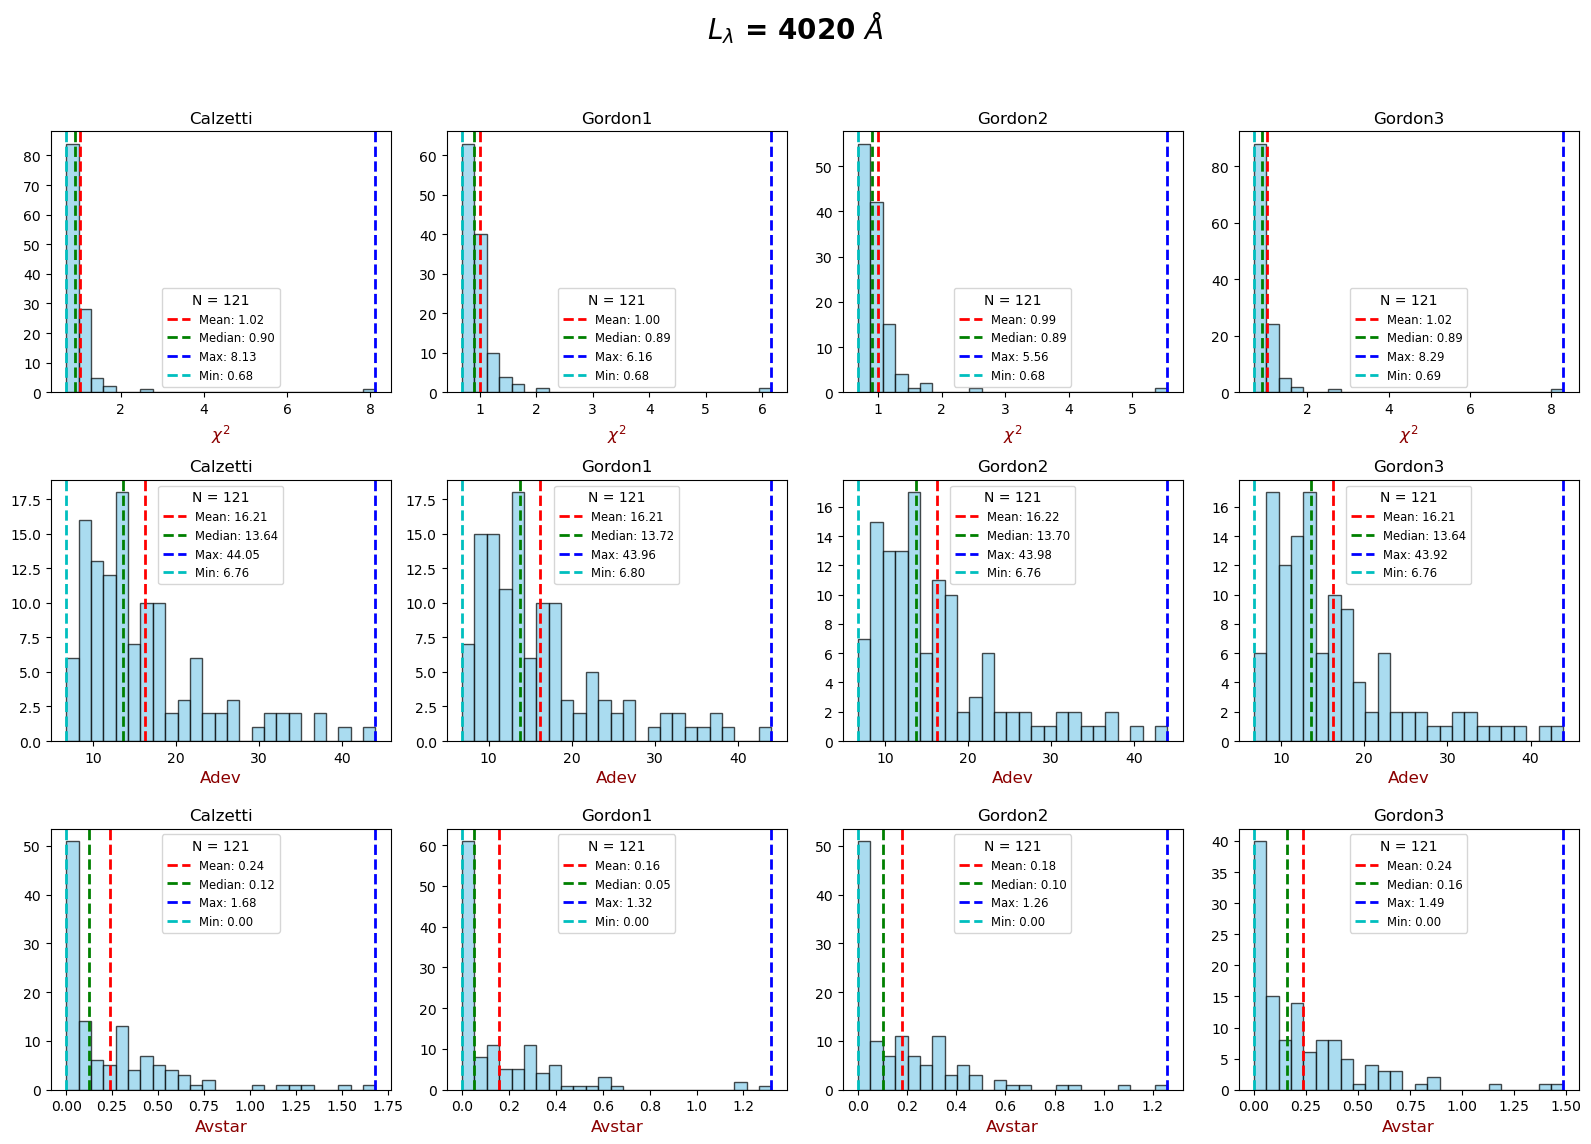

In [ ]:
merit_stats(path ='~/HIIGalaxies/FADO/output_4020/',
            title=r'$L_{\lambda}$ = 4020 $\AA$',
            snr_threshold=0,
            DF_path='/home/hollman/HIIGalaxies/Spectral_synthesis/HIIGsample_data.csv',
            attributes = [[r'$\chi^2$',r'Adev',r'Avstar'],[0,1,2]])